# News Article Categorization

Using NLP to classify news articles into different categories.

Dataset: FlipItNews articles

In [1]:
# Install required packages
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn nltk -q

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download required NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style('whitegrid')
print("Libraries imported successfully")

Libraries imported successfully


## Load Dataset

In [3]:
# Load the news articles dataset
df = pd.read_csv('flipitnews-data.csv')
print(f"Dataset loaded: {len(df)} articles")
df.head()

Dataset loaded: 2225 articles


,Category,Article
0,Technology,tv future in the hands of viewers with home th...
1,Business,worldcom boss left books alone former worldc...
2,Sports,tigers wary of farrell gamble leicester say ...
3,Sports,yeading face newcastle in fa cup premiership s...
4,Entertainment,ocean s twelve raids box office ocean s twelve...


## Exploratory Data Analysis

In [4]:
# Check dataset info
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDataset Info:")
df.info()

Dataset Shape: (2225, 2)

Columns: ['Category', 'Article']

Missing values:
Category    0
Article     0
dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  2225 non-null   object
 1   Article   2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB


In [5]:
# Category distribution
print("Articles per category:")
print(df['Category'].value_counts())

Articles per category:
Category
Sports           511
Business         510
Politics         417
Technology       401
Entertainment    386
Name: count, dtype: int64


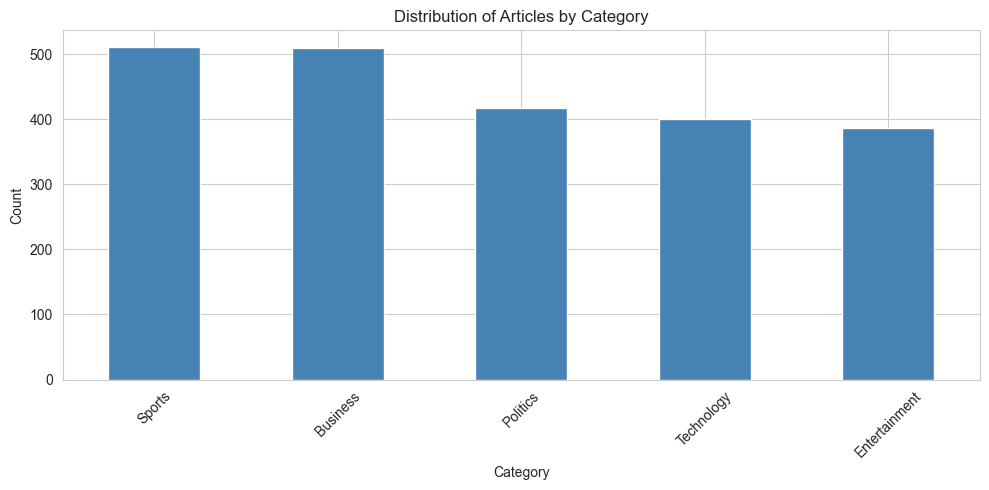

In [6]:
# Visualize distribution
plt.figure(figsize=(10, 5))
df['Category'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Distribution of Articles by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

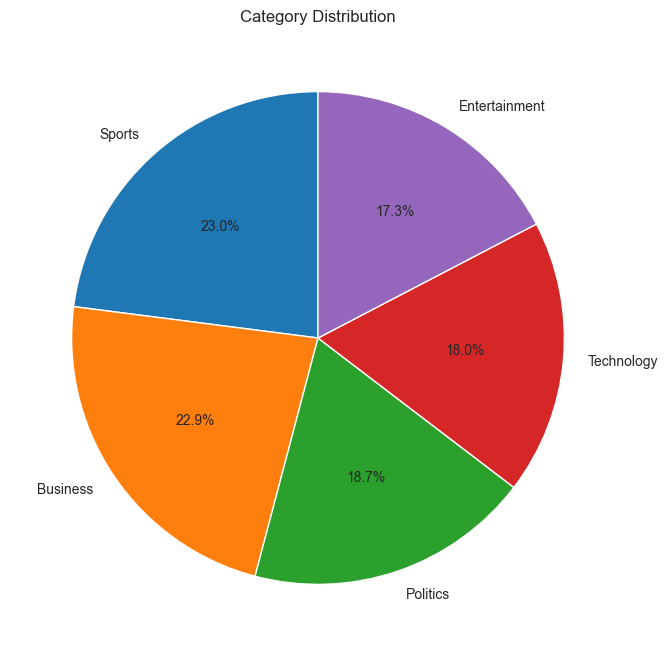

In [7]:
# Pie chart
plt.figure(figsize=(8, 8))
df['Category'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Category Distribution')
plt.ylabel('')
plt.show()

## Text Preprocessing

We need to clean the text data before feeding it to ML models.

In [8]:
def clean_text(text):
    # Remove non-alphabetic characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Lowercase
    text = text.lower()
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    
    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    return ' '.join(tokens)

print("Text cleaning function created")

Text cleaning function created


In [9]:
# Example of text processing
sample = df['Article'].iloc[0]
print("Original:")
print(sample[:200])
print("\n" + "="*50)
print("\nProcessed:")
print(clean_text(sample)[:200])

Original:
tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in


Processed:
tv future hand viewer home theatre system plasma highdefinition tv digital video recorder moving living room way people watch tv radically different five year time according expert panel gathered annu


In [10]:
# Apply to all articles
print("Processing all articles...")
df['cleaned_text'] = df['Article'].apply(clean_text)
print("Done!")

Processing all articles...
Done!


## Feature Engineering

In [11]:
# Encode categories to numbers
le = LabelEncoder()
df['category_encoded'] = le.fit_transform(df['Category'])

print("Category mapping:")
for i, cat in enumerate(le.classes_):
    print(f"{i}: {cat}")

Category mapping:
0: Business
1: Entertainment
2: Politics
3: Sports
4: Technology


In [12]:
# TF-IDF vectorization (usually works better than bag of words)
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['cleaned_text'])
y = df['category_encoded']

print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (2225, 5000)


In [13]:
# Split data - 75% train, 25% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (1668, 5000)
Test set: (557, 5000)


## Model Training

Training multiple classifiers to compare performance.

In [14]:
# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_pred)

print(f"Naive Bayes Accuracy: {nb_accuracy*100:.2f}%")

Naive Bayes Accuracy: 97.49%


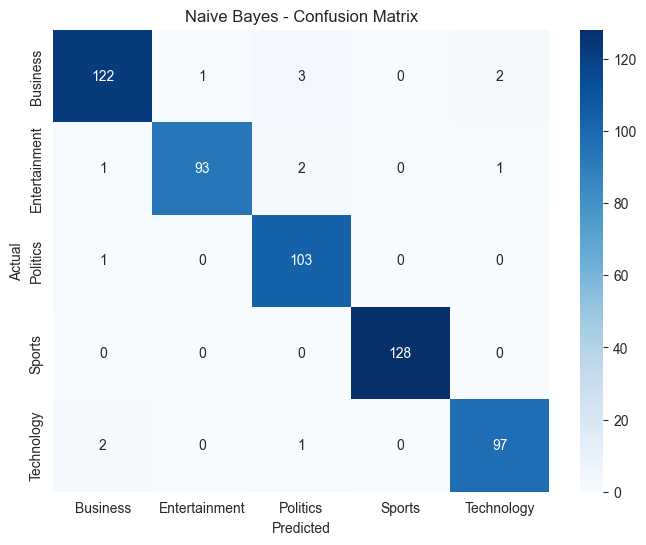

In [15]:
# Confusion matrix for Naive Bayes
cm = confusion_matrix(y_test, nb_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Naive Bayes - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [16]:
# Classification report
print("Naive Bayes Classification Report:")
print(classification_report(y_test, nb_pred, target_names=le.classes_))

Naive Bayes Classification Report:
               precision    recall  f1-score   support

     Business       0.97      0.95      0.96       128
Entertainment       0.99      0.96      0.97        97
     Politics       0.94      0.99      0.97       104
       Sports       1.00      1.00      1.00       128
   Technology       0.97      0.97      0.97       100

     accuracy                           0.97       557
    macro avg       0.97      0.97      0.97       557
 weighted avg       0.98      0.97      0.97       557



Decision Tree Accuracy: 82.76%


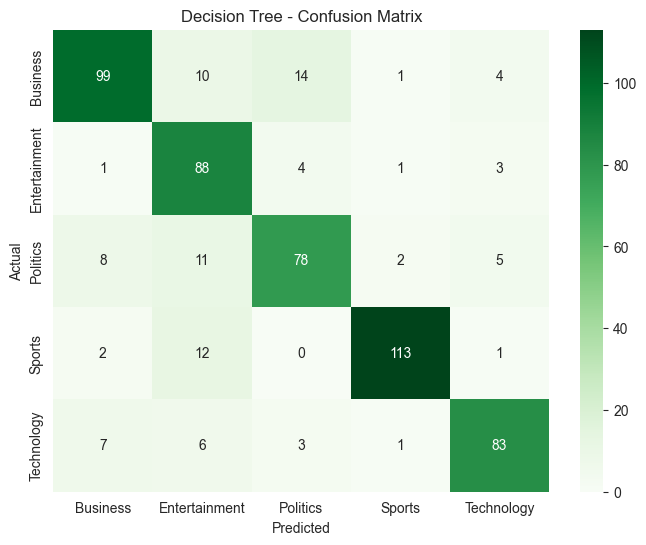

In [17]:
# Decision Tree
dt_model = DecisionTreeClassifier(max_depth=20, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)

print(f"Decision Tree Accuracy: {dt_accuracy*100:.2f}%")

cm = confusion_matrix(y_test, dt_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Decision Tree - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

KNN Accuracy: 94.43%


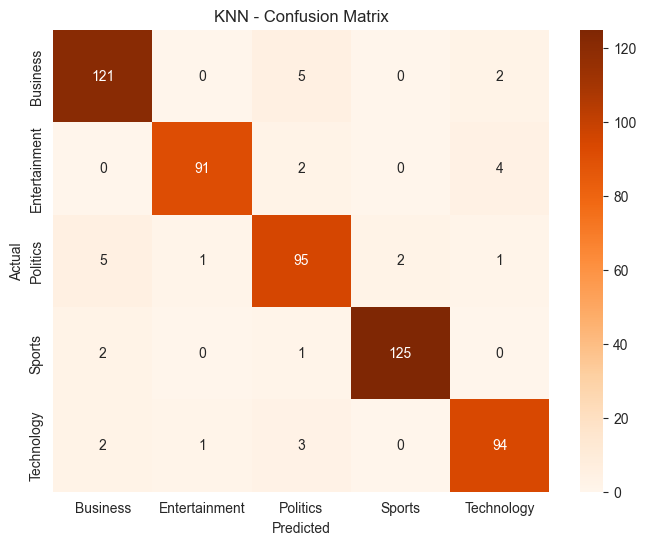

In [18]:
# K-Nearest Neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_pred)

print(f"KNN Accuracy: {knn_accuracy*100:.2f}%")

cm = confusion_matrix(y_test, knn_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('KNN - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Random Forest Accuracy: 95.87%


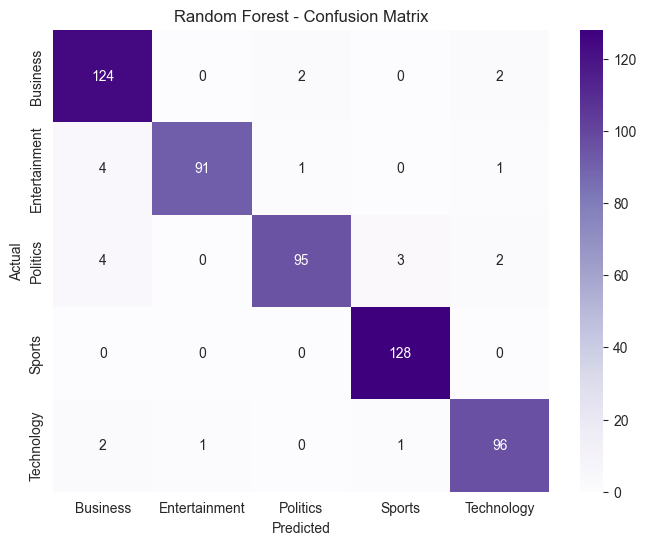

In [19]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_accuracy*100:.2f}%")

cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Model Comparison

In [20]:
# Compare all models
results = {
    'Naive Bayes': nb_accuracy,
    'Decision Tree': dt_accuracy,
    'KNN': knn_accuracy,
    'Random Forest': rf_accuracy
}

results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df['Accuracy %'] = results_df['Accuracy'] * 100
results_df = results_df.sort_values('Accuracy', ascending=False)

print(results_df.to_string(index=False))
print(f"\nBest model: {results_df.iloc[0]['Model']} with {results_df.iloc[0]['Accuracy %']:.2f}% accuracy")

        Model  Accuracy  Accuracy %
  Naive Bayes  0.974865   97.486535
Random Forest  0.958707   95.870736
          KNN  0.944345   94.434470
Decision Tree  0.827648   82.764811

Best model: Naive Bayes with 97.49% accuracy


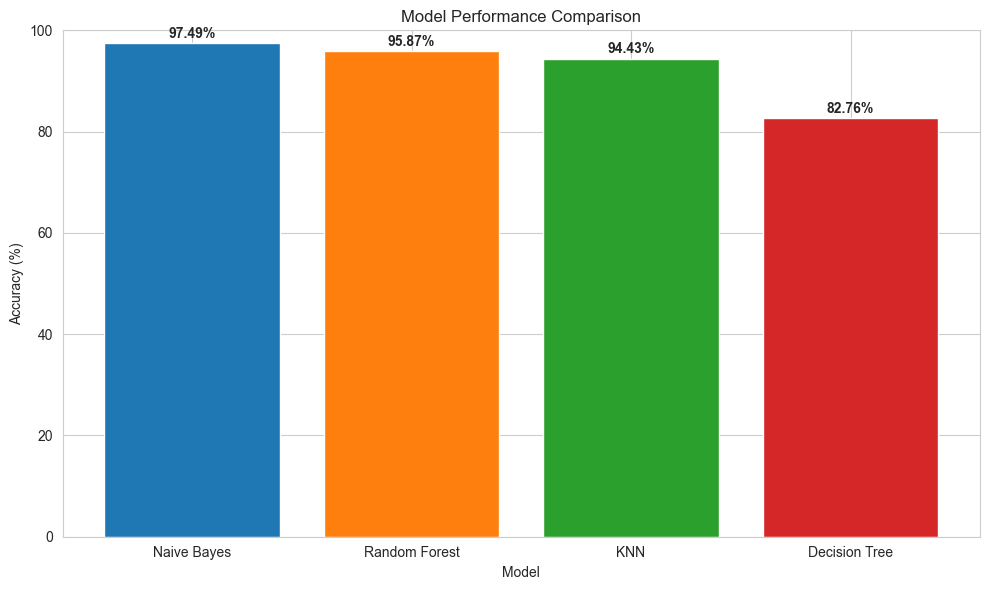

In [21]:
# Plot comparison
plt.figure(figsize=(10, 6))
plt.bar(results_df['Model'], results_df['Accuracy %'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.title('Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.ylim([0, 100])
for i, v in enumerate(results_df['Accuracy %']):
    plt.text(i, v + 1, f'{v:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Questionnaire Answers

**Q1: How many news articles are in the dataset?**  
Answer: {len(df)} articles

**Q2: Most articles are from which category?**  
Answer: {df['Category'].value_counts().index[0]} 

**Q3: Technology articles count**  
Answer: N/A articles

**Q4: What are Stop Words and why remove them?**  
Stop words are common words like 'the', 'is', 'at' that appear frequently but don't add much meaning. We remove them to reduce noise and focus on important words.

**Q5: Stemming vs Lemmatization**  
- Stemming: Crude chopping of word endings (running -> run, better -> bett)
- Lemmatization: Proper reduction to dictionary form (running -> run, better -> good)

**Q6: Bag of Words vs TF-IDF**  
TF-IDF is generally better because it weighs words by importance across documents, not just frequency.

**Q7: Train/test split shapes**  
Train: {X_train.shape[0]} samples  
Test: {X_test.shape[0]} samples

**Q8: Best performing model**  
Answer: See results above

**Q9: Are precision and recall equally important?**  
True - Both matter for news categorization to ensure accurate placement and complete coverage.